Data type: <class 'numpy.ndarray'>
Data shape: (50, 560, 560)


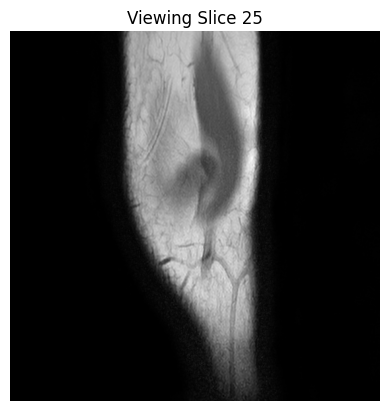

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
data = np.load(r"C:\ML projects\ACL tears\DATASET\processed_sagittal\082_ACL_MEDIAL_LATERAL_MENISCUS.npy")

# 2. Check the type and shape
print("Data type:", type(data))
print("Data shape:", data.shape)

# 3. Since 'data' IS the array, assign it directly
mri_volume = data

# 4. View a slice
# Note: If it's 3D, we take a slice. If it's 2D, we just show it.
if mri_volume.ndim == 3:
    mid_slice = mri_volume.shape[0] // 2
    plt.imshow(mri_volume[mid_slice, :, :], cmap='gray')
    plt.title(f"Viewing Slice {mid_slice}")
elif mri_volume.ndim == 2:
    plt.imshow(mri_volume, cmap='gray')
    plt.title("Viewing 2D Array")
else:
    print(f"Unexpected dimensions: {mri_volume.ndim}. Shape is {mri_volume.shape}")

plt.axis('off')
plt.show()

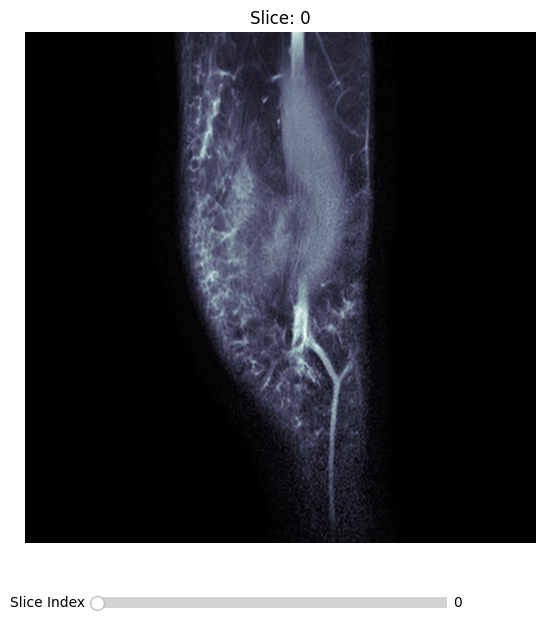

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 1. Load the data (which is already a numpy array)
mri_volume = np.load(r"C:\ML projects\ACL tears\DATASET\processed_sagittal\082_ACL_MEDIAL_LATERAL_MENISCUS.npy")

# Verify it is 3D
if mri_volume.ndim != 3:
    raise ValueError(f"Expected a 3D array, but got shape {mri_volume.shape}")

# 2. Setup the figure and axis
fig, ax = plt.subplots(figsize=(7, 7))
plt.subplots_adjust(bottom=0.15) # Make room for the slider

# 3. Display the first slice
# Adjust cmap to 'bone' or 'gray' for a medical look
initial_slice = 0
im = ax.imshow(mri_volume[initial_slice, :, :], cmap='bone')
ax.set_title(f"Slice: {initial_slice}")
ax.axis('off')

# 4. Create the Slider
# [left, bottom, width, height]
ax_slider = plt.axes([0.25, 0.05, 0.5, 0.03])
slider = Slider(
    ax=ax_slider,
    label='Slice Index ',
    valmin=0,
    valmax=mri_volume.shape[0] - 1,
    valinit=initial_slice,
    valfmt='%0.0f'
)

# 5. The update function
def update(val):
    idx = int(slider.val)
    im.set_data(mri_volume[idx, :, :])
    ax.set_title(f"Slice: {idx}")
    fig.canvas.draw_idle()

# Register the update function with the slider
slider.on_changed(update)

plt.show()

In [6]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


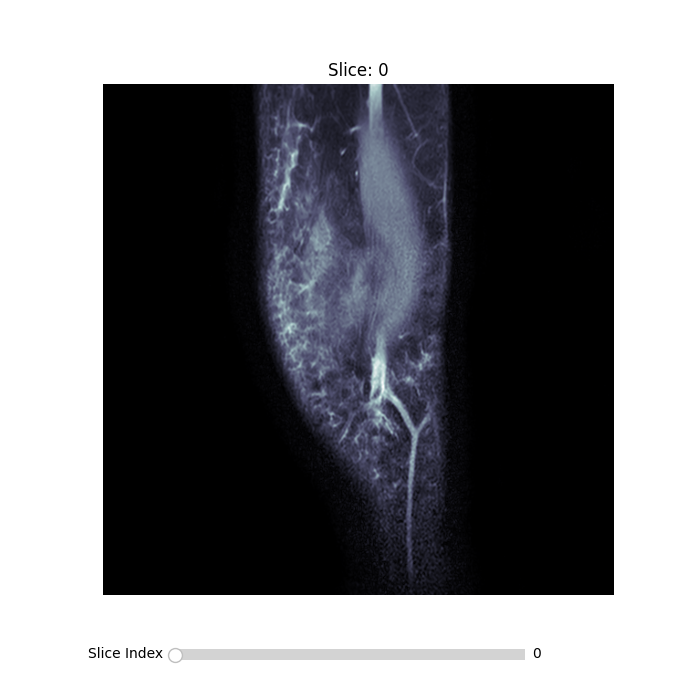

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.widgets import Slider

# 1. Load the data (which is already a numpy array)
mri_volume = np.load(r"C:\ML projects\ACL tears\DATASET\processed_sagittal\082_ACL_MEDIAL_LATERAL_MENISCUS.npy")

# Verify it is 3D
if mri_volume.ndim != 3:
    raise ValueError(f"Expected a 3D array, but got shape {mri_volume.shape}")

# 2. Setup the figure and axis
fig, ax = plt.subplots(figsize=(7, 7))
plt.subplots_adjust(bottom=0.15) # Make room for the slider

# 3. Display the first slice
# Adjust cmap to 'bone' or 'gray' for a medical look
initial_slice = 0
im = ax.imshow(mri_volume[initial_slice, :, :], cmap='bone')
ax.set_title(f"Slice: {initial_slice}")
ax.axis('off')

# 4. Create the Slider
# [left, bottom, width, height]
ax_slider = plt.axes([0.25, 0.05, 0.5, 0.03])
slider = Slider(
    ax=ax_slider,
    label='Slice Index ',
    valmin=0,
    valmax=mri_volume.shape[0] - 1,
    valinit=initial_slice,
    valfmt='%0.0f'
)

# 5. The update function
def update(val):
    idx = int(slider.val)
    im.set_data(mri_volume[idx, :, :])
    ax.set_title(f"Slice: {idx}")
    fig.canvas.draw_idle()

# Register the update function with the slider
slider.on_changed(update)

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# 1. Load the data
mri_volume = np.load(r"C:\ML projects\ACL tears\DATASET\processed_sagittal\082_ACL_MEDIAL_LATERAL_MENISCUS.npy")

# 2. Define the plotting function
def browse_images(slices):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(slices, cmap='bone')
    ax.axis('off')
    plt.show()

# 3. Create the interactive slider
interact(
    lambda idx: browse_images(mri_volume[idx, :, :]), 
    idx=IntSlider(
        min=0, 
        max=mri_volume.shape[0]-1, 
        step=1, 
        value=0,
        description='Slice:'
    )
);

interactive(children=(IntSlider(value=0, description='Slice:', max=49), Output()), _dom_classes=('widget-inter…